# 06. LocalFit v1 Colab Output Review

이 노트북의 목적은 **학습 결과물을 모델 추론 전에 먼저 검산**하는 것이다.

확인할 것:

1. Colab output이 정상적으로 내려왔는지
2. full/smoke run의 checkpoint와 log가 있는지
3. full 학습이 끝까지 완료되었는지
4. epoch별 train loss와 validation metric이 어떻게 움직였는지
5. 어떤 checkpoint를 다음 `get_lanes` 검증에 사용할지

주의: 여기서 보는 F1은 **이번 local-fit label dataset의 validation F1**이다. 공식 CULane 논문 수치나 이전 v1/v2 실험 수치와 절대값으로 직접 비교하면 안 된다. 그래도 같은 학습 안에서 best epoch을 고르는 데는 의미가 있다.


In [1]:
from pathlib import Path
import json
import re
import math
import shutil

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild')
COLAB_OUT = ROOT / 'colab_outputs'
REVIEW_DIR = ROOT / 'review_outputs' / '06_colab_output_review'
TABLE_DIR = REVIEW_DIR / 'tables'
FIG_DIR = REVIEW_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FULL_NAME = 'MapLane_LocalFit_Field12_v1_full'
SMOKE_NAME = 'MapLane_LocalFit_Field12_v1_smoke'

print('ROOT:', ROOT)
print('COLAB_OUT exists:', COLAB_OUT.exists())
print('REVIEW_DIR:', REVIEW_DIR)


ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild
COLAB_OUT exists: True
REVIEW_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\06_colab_output_review


## 1. Output 폴더 구조 확인

Colab에서 내려온 결과가 압축 해제되면 `colab_outputs` 아래에 다음 폴더가 있어야 한다.

- `MapLane_LocalFit_Field12_v1_full/`
- `MapLane_LocalFit_Field12_v1_smoke/`
- `checkpoint_mirror/`
- `debug_logs/`
- `meta/`

여기서 다음 단계의 핵심은 full run의 `ckpt/best.pth`이다.


In [2]:
import os


def safe_tree_stats(root: Path):
    file_count = 0
    total_bytes = 0
    skipped_dirs = 0
    for dirpath, dirnames, filenames in os.walk(root, topdown=True, onerror=lambda err: None):
        # Do not recurse into symlink/junction-like directories. Some Colab outputs
        # preserve prediction subpaths that can become invalid on Windows extraction.
        keep = []
        for d in dirnames:
            dp = Path(dirpath) / d
            try:
                if not dp.is_symlink():
                    keep.append(d)
                else:
                    skipped_dirs += 1
            except OSError:
                skipped_dirs += 1
        dirnames[:] = keep
        for name in filenames:
            fp = Path(dirpath) / name
            try:
                if fp.is_file():
                    file_count += 1
                    total_bytes += fp.stat().st_size
            except (OSError, FileNotFoundError):
                pass
    return file_count, total_bytes, skipped_dirs

for p in sorted(COLAB_OUT.iterdir()):
    if p.is_dir():
        file_count, total_bytes, skipped_dirs = safe_tree_stats(p)
        print(f'{p.name:45s} files={file_count:5d} size_gb={total_bytes/1024**3:6.2f} skipped_dirs={skipped_dirs}')
    else:
        print(f'{p.name:45s} file size_gb={p.stat().st_size/1024**3:6.2f}')


checkpoint_mirror                             files=   11 size_gb=  1.16 skipped_dirs=0
debug_logs                                    files=    2 size_gb=  0.00 skipped_dirs=0
MapLane_LocalFit_Field12_v1_full              files=   76 size_gb=  0.90 skipped_dirs=0
MapLane_LocalFit_Field12_v1_smoke             files=   71 size_gb=  0.26 skipped_dirs=0
meta                                          files=    5 size_gb=  0.00 skipped_dirs=0


## 2. Run directory와 checkpoint 확인

full run과 smoke run의 최신 실행 폴더를 찾고 checkpoint 목록을 확인한다.

이번 실험에서는 full run의 `best.pth`를 다음 노트북에서 우선 사용한다. 단, validation metric은 fallback NMS의 영향을 받으므로, 이후 `get_lanes` overlay 검증에서 `best.pth`와 마지막 epoch checkpoint를 같이 확인할 수 있다.


In [3]:
def latest_run_dir(run_name: str):
    root = COLAB_OUT / run_name
    if not root.exists():
        return None
    dirs = [p for p in root.iterdir() if p.is_dir()]
    return max(dirs, key=lambda p: p.stat().st_mtime) if dirs else None

FULL_RUN = latest_run_dir(FULL_NAME)
SMOKE_RUN = latest_run_dir(SMOKE_NAME)

print('FULL_RUN:', FULL_RUN)
print('SMOKE_RUN:', SMOKE_RUN)

assert FULL_RUN is not None, 'full run directory not found'
assert (FULL_RUN / 'log.txt').exists(), 'full log.txt not found'
assert (FULL_RUN / 'ckpt' / 'best.pth').exists(), 'full best.pth not found'

ckpt_rows = []
for run_name, run_dir in [('full', FULL_RUN), ('smoke', SMOKE_RUN)]:
    if run_dir is None:
        continue
    for p in sorted((run_dir / 'ckpt').glob('*.pth')):
        ckpt_rows.append({
            'run': run_name,
            'name': p.name,
            'path': str(p),
            'size_mb': p.stat().st_size / 1024**2,
            'modified': pd.Timestamp.fromtimestamp(p.stat().st_mtime),
        })
ckpt_df = pd.DataFrame(ckpt_rows)
display(ckpt_df)
ckpt_df.to_csv(TABLE_DIR / 'checkpoint_inventory.csv', index=False, encoding='utf-8-sig')


FULL_RUN: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8
SMOKE_RUN: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_smoke\20260509_101443_lr_1e-04_b_8


,run,name,path,size_mb,modified
0,full,1.pth,~\02_Projects\University\26-1_Em...,131.625125,2026-05-09 19:33:24
1,full,11.pth,~\02_Projects\University\26-1_Em...,131.631863,2026-05-09 20:40:16
2,full,3.pth,~\02_Projects\University\26-1_Em...,131.625369,2026-05-09 19:46:38
3,full,5.pth,~\02_Projects\University\26-1_Em...,131.625369,2026-05-09 20:00:02
4,full,7.pth,~\02_Projects\University\26-1_Em...,131.625369,2026-05-09 20:13:32
5,full,9.pth,~\02_Projects\University\26-1_Em...,131.625369,2026-05-09 20:26:56
6,full,best.pth,~\02_Projects\University\26-1_Em...,131.632826,2026-05-09 20:43:08
7,smoke,0.pth,~\02_Projects\University\26-1_Em...,131.625125,2026-05-09 19:20:08
8,smoke,best.pth,~\02_Projects\University\26-1_Em...,131.632826,2026-05-09 19:22:27


## 3. Meta 파일 확인

`meta`에는 dataset build summary와 validation summary, 그리고 학습에 사용한 config 복사본이 있다. 여기서 dataset row 수와 validation issue count를 다시 확인한다.


In [4]:
def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))

meta_dir = COLAB_OUT / 'meta'
for p in sorted(meta_dir.glob('*')):
    print(p.name, p.stat().st_size)

build_summary = load_json(meta_dir / 'build_summary.json')
validation_summary = load_json(meta_dir / 'validation_summary.json')
run_manifest = load_json(meta_dir / 'run_manifest.json')

print('\n[build_summary]')
display(pd.Series(build_summary, name='value').to_frame())
print('\n[validation_summary]')
display(pd.Series(validation_summary, name='value').to_frame())
print('\n[run_manifest]')
display(pd.Series(run_manifest, name='value').to_frame())

assert validation_summary.get('issue_count', 0) == 0, 'dataset validation issue_count is not zero'


build_summary.json 2167
MapLane_LocalFit_Field12_v1_ResNet18_full.py 3522
MapLane_LocalFit_Field12_v1_ResNet18_smoke.py 3520
run_manifest.json 701
validation_summary.json 325

[build_summary]


,value
name,map_culane_localfit_train_field1_field2_v1
dataset_root,~\02_Projects\University\26-1_Em...
source_review_root,~\02_Projects\University\26-1_Em...
source_manifest,~\02_Projects\University\26-1_Em...
source_lines,~\02_Projects\University\26-1_Em...
policy,"{'accept_status': 'usable_auto only', 'exclude..."
geometry,"{'raw_width': 1296, 'raw_height': 972, 'cut_he..."
counts,"{'input_frames': 9375, 'usable_auto_frames': 8..."
status_counts_source,"{'usable_auto': 8616, 'review_needed': 727, 'r..."
split_counts,"{'train': 6894, 'val': 1722}"



[validation_summary]


,value
dataset_root,~\02_Projects\University\26-1_Em...
counts,"{'train_gt.txt': 6894, 'val.txt': 1722, 'test...."
issue_count,0
issues_sample,[]



[run_manifest]


,value
drive_dir,/content/drive/MyDrive/Colab Notebooks/26-1학기_...
repo_dir,/content/CLRKDNet
dataset_name,map_culane_localfit_train_field1_field2_v1
pretrained,ResNet18_CULane.pth
run_prefix,MapLane_LocalFit_Field12_v1
smoke_dir,/content/CLRKDNet/work_dirs/MapLane_LocalFit_F...
full_dir,/content/CLRKDNet/work_dirs/MapLane_LocalFit_F...
train_rows,6894
val_rows,1722
test_rows,1722


## 4. Full log 파싱

`log.txt`에서 train loss와 validation metric을 파싱한다.

- train log: `loss`, `cls_loss`, `reg_xytl_loss`, `seg_loss`, `iou_loss`
- val log: `F1@IoU=0.50`, mean F1, precision/recall
- best log: `Best metric`, `epoch_best`


In [5]:
log_path = FULL_RUN / 'log.txt'
log_text = log_path.read_text(encoding='utf-8', errors='replace')
print('log_path:', log_path)
print('log_size_kb:', log_path.stat().st_size / 1024)

train_re = re.compile(
    r'epoch:\s*(?P<epoch>\d+)\s+step:\s*(?P<step>\d+)\s+lr:\s*(?P<lr>[0-9.eE+-]+)\s+'
    r'loss:\s*(?P<loss>[0-9.eE+-]+)\s+cls_loss:\s*(?P<cls_loss>[0-9.eE+-]+)\s+'
    r'reg_xytl_loss:\s*(?P<reg_xytl_loss>[0-9.eE+-]+)\s+seg_loss:\s*(?P<seg_loss>[0-9.eE+-]+)\s+'
    r'iou_loss:\s*(?P<iou_loss>[0-9.eE+-]+)\s+stage_0_acc:\s*(?P<stage_0_acc>[0-9.eE+-]+)'
)
metric_re = re.compile(r' - INFO - metric:\s*(?P<metric>[0-9.eE+-]+)')
best_re = re.compile(r'Best metric:\s*(?P<best>[0-9.eE+-]+)\s+epoch_best:(?P<epoch_best>\d+)')
iou_re = re.compile(
    r'iou thr:\s*(?P<thr>[0-9.]+),\s*tp:\s*(?P<tp>\d+),\s*fp:\s*(?P<fp>\d+),\s*fn:\s*(?P<fn>\d+),'
    r'precision:\s*(?P<precision>[0-9.eE+-]+),\s*recall:\s*(?P<recall>[0-9.eE+-]+),\s*f1:\s*(?P<f1>[0-9.eE+-]+)'
)
mean_re = re.compile(
    r'mean result, total_tp:\s*(?P<tp>\d+),\s*total_fp:\s*(?P<fp>\d+),\s*total_fn:\s*(?P<fn>\d+),'
    r'precision:\s*(?P<precision>[0-9.eE+-]+),\s*recall:\s*(?P<recall>[0-9.eE+-]+),\s*f1:\s*(?P<f1>[0-9.eE+-]+)'
)

train_rows = []
val_rows = []
iou_rows = []
best_rows = []

current_epoch = None
in_val_block = False
current_iou_rows = []
pending_mean = None

for line in log_text.splitlines():
    m = train_re.search(line)
    if m:
        row = {k: float(v) for k, v in m.groupdict().items()}
        row['epoch'] = int(row['epoch'])
        row['step'] = int(row['step'])
        current_epoch = row['epoch']
        train_rows.append(row)
        continue

    if 'Calculating metric for List:' in line:
        in_val_block = line.strip().endswith('/list/val.txt') or 'list/val.txt' in line
        if in_val_block:
            current_iou_rows = []
            pending_mean = None
        continue

    m = iou_re.search(line)
    if m and in_val_block:
        row = {k: float(v) for k, v in m.groupdict().items()}
        row['tp'] = int(row['tp'])
        row['fp'] = int(row['fp'])
        row['fn'] = int(row['fn'])
        row['eval_epoch'] = current_epoch
        current_iou_rows.append(row)
        continue

    m = mean_re.search(line)
    if m and in_val_block:
        pending_mean = {k: float(v) for k, v in m.groupdict().items()}
        pending_mean['tp'] = int(pending_mean['tp'])
        pending_mean['fp'] = int(pending_mean['fp'])
        pending_mean['fn'] = int(pending_mean['fn'])
        pending_mean['eval_epoch'] = current_epoch
        iou_rows.extend(current_iou_rows)
        continue

    m = metric_re.search(line)
    if m:
        val_rows.append({
            'eval_epoch': current_epoch,
            'metric_f1_iou_050': float(m.group('metric')),
            'mean_f1': pending_mean['f1'] if pending_mean else math.nan,
            'mean_precision': pending_mean['precision'] if pending_mean else math.nan,
            'mean_recall': pending_mean['recall'] if pending_mean else math.nan,
        })
        in_val_block = False
        continue

    m = best_re.search(line)
    if m:
        best_rows.append({
            'seen_after_epoch': current_epoch,
            'best_metric': float(m.group('best')),
            'epoch_best': int(m.group('epoch_best')),
        })

train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows).drop_duplicates(subset=['eval_epoch'], keep='last')
iou_df = pd.DataFrame(iou_rows)
best_df = pd.DataFrame(best_rows)

print('train rows:', len(train_df))
print('val rows:', len(val_df))
print('iou rows:', len(iou_df))
print('best rows:', len(best_df))

display(train_df.tail())
display(val_df)
display(best_df)

train_df.to_csv(TABLE_DIR / 'train_log.csv', index=False, encoding='utf-8-sig')
val_df.to_csv(TABLE_DIR / 'validation_metrics.csv', index=False, encoding='utf-8-sig')
iou_df.to_csv(TABLE_DIR / 'validation_iou_thresholds.csv', index=False, encoding='utf-8-sig')
best_df.to_csv(TABLE_DIR / 'best_metric_history.csv', index=False, encoding='utf-8-sig')


log_path: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8\log.txt
log_size_kb: 174.4716796875
train rows: 538
val rows: 6
iou rows: 60
best rows: 6


,epoch,step,lr,loss,cls_loss,reg_xytl_loss,seg_loss,iou_loss,stage_0_acc
533,11,10243,0.0,1.0870,0.2749,0.1887,0.1502,0.4731,99.3317
534,11,10263,0.0,1.2063,0.3020,0.2285,0.1611,0.5147,99.2671
535,11,10283,0.0,1.3086,0.3215,0.3029,0.1566,0.5276,99.1927
536,11,10303,0.0,1.0690,0.2622,0.2058,0.1544,0.4465,99.3099
537,11,10323,0.0,1.0702,0.2906,0.1842,0.1541,0.4412,99.2643


,eval_epoch,metric_f1_iou_050,mean_f1,mean_precision,mean_recall
0,1,0.489730,0.248908,0.272004,0.229428
1,3,0.643289,0.385446,0.401844,0.370334
2,5,0.689614,0.417702,0.417516,0.417889
3,7,0.716436,0.424774,0.428906,0.420722
4,9,0.741654,0.462075,0.466141,0.458080
5,11,0.747845,0.458055,0.464876,0.451431


,seen_after_epoch,best_metric,epoch_best
0,1,0.489730,1
1,3,0.643289,3
2,5,0.689614,5
3,7,0.716436,7
4,9,0.741654,9
5,11,0.747845,11


## 5. 결과 요약

여기서는 full 학습이 정상 완료되었는지, best checkpoint가 어느 epoch인지, 다음 단계에서 어떤 모델을 써야 하는지를 정리한다.


In [6]:
assert len(val_df) > 0, 'no validation metrics parsed'
final_best = best_df.iloc[-1] if len(best_df) else None
best_epoch = int(final_best['epoch_best']) if final_best is not None else int(val_df.loc[val_df['metric_f1_iou_050'].idxmax(), 'eval_epoch'])
best_metric = float(final_best['best_metric']) if final_best is not None else float(val_df['metric_f1_iou_050'].max())
last_val = val_df.iloc[-1]

best_ckpt = FULL_RUN / 'ckpt' / 'best.pth'
last_epoch_ckpt = FULL_RUN / 'ckpt' / f'{best_epoch}.pth'
if not last_epoch_ckpt.exists():
    last_epoch_ckpt = None

summary_md = f"""
### Colab Output Review Summary

- full 학습 run: `{FULL_RUN.name}`
- full log: `{log_path.name}`
- checkpoint 개수: `{len(list((FULL_RUN / 'ckpt').glob('*.pth')))}`
- best checkpoint: `{best_ckpt}`
- best epoch: `{best_epoch}`
- best F1@IoU=0.50: `{best_metric:.6f}`
- last validation epoch: `{int(last_val['eval_epoch'])}`
- last validation F1@IoU=0.50: `{float(last_val['metric_f1_iou_050']):.6f}`
- last validation mean F1: `{float(last_val['mean_f1']):.6f}`

해석:

- full 학습은 끝까지 완료되었고 `best.pth`가 존재한다.
- validation F1@0.50이 학습 후반까지 계속 상승했다.
- 이번 metric은 local-fit label 기준 validation metric이므로 이전 실험이나 논문 수치와 절대 비교하지 않는다.
- 다음 단계에서는 `best.pth`를 우선 사용해서 공식 `get_lanes` 결과가 GT `.lines.txt`와 비슷하게 나오는지 overlay로 확인한다.
"""
display(Markdown(summary_md))

(TABLE_DIR / 'review_summary.md').write_text(summary_md, encoding='utf-8')



### Colab Output Review Summary

- full 학습 run: `20260509_102232_lr_1e-04_b_8`
- full log: `log.txt`
- checkpoint 개수: `7`
- best checkpoint: `~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8\ckpt\best.pth`
- best epoch: `11`
- best F1@IoU=0.50: `0.747845`
- last validation epoch: `11`
- last validation F1@IoU=0.50: `0.747845`
- last validation mean F1: `0.458055`

해석:

- full 학습은 끝까지 완료되었고 `best.pth`가 존재한다.
- validation F1@0.50이 학습 후반까지 계속 상승했다.
- 이번 metric은 local-fit label 기준 validation metric이므로 이전 실험이나 논문 수치와 절대 비교하지 않는다.
- 다음 단계에서는 `best.pth`를 우선 사용해서 공식 `get_lanes` 결과가 GT `.lines.txt`와 비슷하게 나오는지 overlay로 확인한다.


778

## 6. Train loss curve

초반에는 pretrained CULane checkpoint에서 우리 local-fit label로 빠르게 적응한다. loss가 후반까지 천천히 내려가면 학습은 정상적으로 진행된 것이다.


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\06_colab_output_review\figures\train_loss_curve.png


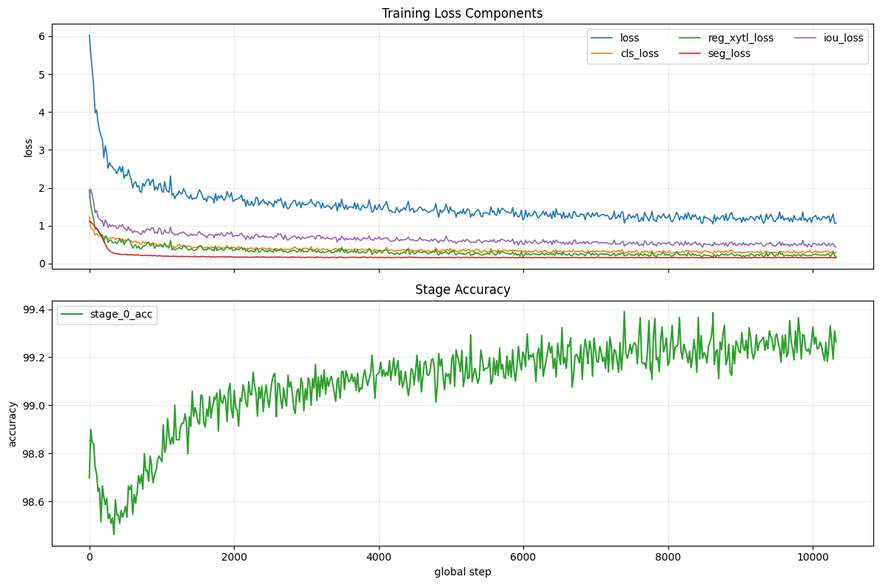

In [7]:
if len(train_df):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    ax = axes[0]
    for col in ['loss', 'cls_loss', 'reg_xytl_loss', 'seg_loss', 'iou_loss']:
        ax.plot(train_df['step'], train_df[col], label=col, linewidth=1.2)
    ax.set_title('Training Loss Components')
    ax.set_ylabel('loss')
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3)

    ax = axes[1]
    ax.plot(train_df['step'], train_df['stage_0_acc'], label='stage_0_acc', color='tab:green')
    ax.set_title('Stage Accuracy')
    ax.set_xlabel('global step')
    ax.set_ylabel('accuracy')
    ax.grid(True, alpha=0.25)
    ax.legend()

    fig.tight_layout()
    out = FIG_DIR / 'train_loss_curve.png'
    fig.savefig(out, dpi=160)
    print('saved:', out)
    plt.show()


## 7. Validation metric curve

`metric_f1_iou_050`은 runner가 `best.pth`를 고를 때 사용한 metric이다. `mean_f1`은 IoU 0.50~0.95 평균이라 더 엄격하다.


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\06_colab_output_review\figures\validation_metric_curve.png


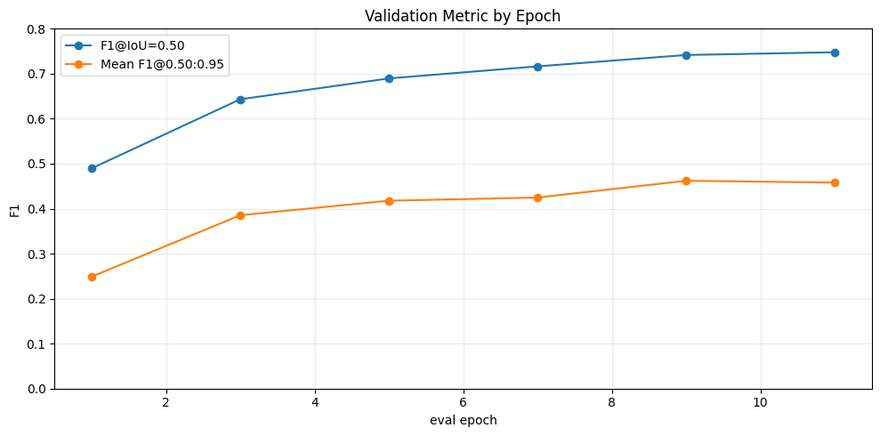

,eval_epoch,metric_f1_iou_050,mean_f1,mean_precision,mean_recall
0,1,0.489730,0.248908,0.272004,0.229428
1,3,0.643289,0.385446,0.401844,0.370334
2,5,0.689614,0.417702,0.417516,0.417889
3,7,0.716436,0.424774,0.428906,0.420722
4,9,0.741654,0.462075,0.466141,0.458080
5,11,0.747845,0.458055,0.464876,0.451431


In [8]:
if len(val_df):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(val_df['eval_epoch'], val_df['metric_f1_iou_050'], marker='o', label='F1@IoU=0.50')
    ax.plot(val_df['eval_epoch'], val_df['mean_f1'], marker='o', label='Mean F1@0.50:0.95')
    ax.set_title('Validation Metric by Epoch')
    ax.set_xlabel('eval epoch')
    ax.set_ylabel('F1')
    ax.set_ylim(0, max(0.8, float(val_df['metric_f1_iou_050'].max()) + 0.05))
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    out = FIG_DIR / 'validation_metric_curve.png'
    fig.savefig(out, dpi=160)
    print('saved:', out)
    plt.show()

display(val_df)


## 8. Best epoch의 IoU threshold별 성능

IoU threshold가 높아질수록 F1이 낮아지는 것은 정상이다. 0.50에서 높은 점수가 나오고 0.80 이상에서 급격히 떨어진다면, 대략적인 lane 방향은 맞지만 정밀한 geometry는 아직 흔들릴 수 있다는 뜻이다.


,thr,tp,fp,fn,precision,recall,f1,eval_epoch
50,0.50,2472,785,882,0.758981,0.737030,0.747845,11
51,0.55,2348,909,1006,0.720909,0.700060,0.710331,11
52,0.60,2194,1063,1160,0.673626,0.654144,0.663742,11
53,0.65,2011,1246,1343,0.617439,0.599583,0.608380,11
54,0.70,1851,1406,1503,0.568314,0.551878,0.559976,11
55,0.75,1609,1648,1745,0.494013,0.479726,0.486764,11
56,0.80,1273,1984,2081,0.390850,0.379547,0.385116,11
57,0.85,849,2408,2505,0.260669,0.253131,0.256845,11
58,0.90,441,2816,2913,0.135401,0.131485,0.133414,11
59,0.95,93,3164,3261,0.028554,0.027728,0.028135,11


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\06_colab_output_review\figures\best_epoch_iou_threshold_curve.png


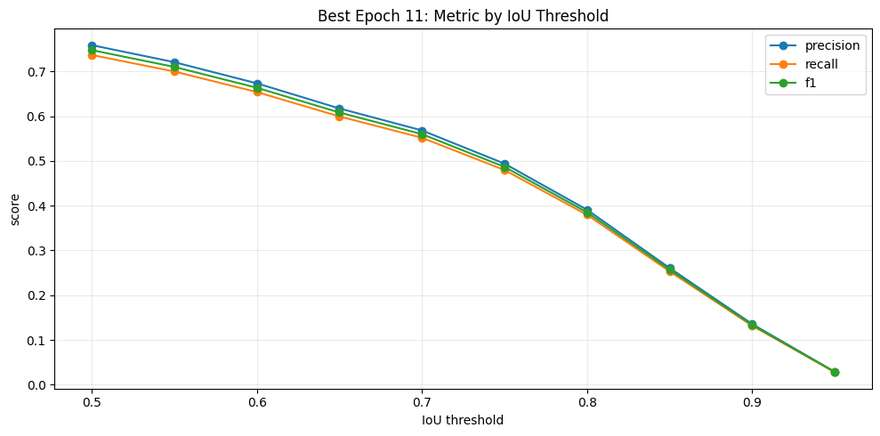

In [9]:
if len(iou_df):
    best_iou_df = iou_df[iou_df['eval_epoch'] == best_epoch].copy()
    if best_iou_df.empty:
        best_iou_df = iou_df[iou_df['eval_epoch'] == iou_df['eval_epoch'].max()].copy()
    display(best_iou_df)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(best_iou_df['thr'], best_iou_df['precision'], marker='o', label='precision')
    ax.plot(best_iou_df['thr'], best_iou_df['recall'], marker='o', label='recall')
    ax.plot(best_iou_df['thr'], best_iou_df['f1'], marker='o', label='f1')
    ax.set_title(f'Best Epoch {best_epoch}: Metric by IoU Threshold')
    ax.set_xlabel('IoU threshold')
    ax.set_ylabel('score')
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    out = FIG_DIR / 'best_epoch_iou_threshold_curve.png'
    fig.savefig(out, dpi=160)
    print('saved:', out)
    plt.show()


## 9. Debug log와 recorder log tail 확인

여기서는 에러가 있었는지 마지막 로그를 확인한다. 정상 학습이면 `Best metric` 이후 fatal traceback이 없어야 한다.


In [10]:
def safe_console_text(text: str) -> str:
    # Windows console may not render tqdm block characters copied from Colab logs.
    return text.encode('cp949', errors='replace').decode('cp949')


def print_tail(label: str, lines, n=40):
    print(f'\n[{label}]')
    print(safe_console_text('\n'.join(lines[-n:])))


debug_full = COLAB_OUT / 'debug_logs' / f'{FULL_NAME}_subprocess_output.txt'
print('debug_full exists:', debug_full.exists(), 'size:', debug_full.stat().st_size if debug_full.exists() else None)

print_tail('full log tail', log_text.splitlines())

if debug_full.exists():
    dbg_text = debug_full.read_text(encoding='utf-8', errors='replace')
    print_tail('debug log tail', dbg_text.splitlines())
    assert 'Traceback (most recent call last)' not in dbg_text, 'debug log contains traceback'


debug_full exists: True size: 269174

[full log tail]
2026-05-09 11:39:22,412 - clrkd.utils.recorder - INFO - epoch: 11  step: 10183  lr: 0.000000  loss: 1.1878  cls_loss: 0.3328  reg_xytl_loss: 0.2209  seg_loss: 0.1563  iou_loss: 0.4779  stage_0_acc: 99.2611  data: 0.0872  batch: 0.3918  eta: 0:00:55
2026-05-09 11:39:28,910 - clrkd.utils.recorder - INFO - epoch: 11  step: 10203  lr: 0.000000  loss: 1.2139  cls_loss: 0.3251  reg_xytl_loss: 0.2662  seg_loss: 0.1505  iou_loss: 0.4721  stage_0_acc: 99.1829  data: 0.0901  batch: 0.3253  eta: 0:00:47
2026-05-09 11:39:37,079 - clrkd.utils.recorder - INFO - epoch: 11  step: 10223  lr: 0.000000  loss: 1.2601  cls_loss: 0.3215  reg_xytl_loss: 0.2423  seg_loss: 0.1594  iou_loss: 0.5368  stage_0_acc: 99.2448  data: 0.0814  batch: 0.4095  eta: 0:00:40
2026-05-09 11:39:43,456 - clrkd.utils.recorder - INFO - epoch: 11  step: 10243  lr: 0.000000  loss: 1.0870  cls_loss: 0.2749  reg_xytl_loss: 0.1887  seg_loss: 0.1502  iou_loss: 0.4731  stage_0_acc: 9

## 10. 다음 단계

이 노트북에서 확인해야 할 결론은 하나다.

> `best.pth`가 정상적으로 만들어졌고, validation metric이 충분히 상승했는가?

이 조건이 만족되면 다음 노트북은 **공식 `get_lanes` 방식의 lane detector 검증**으로 간다.

다음 노트북의 목표:

1. `best.pth` 로드
2. 공식 전처리 계약 확인: BGR, resize 800x320, float32 `/255.0`
3. PyTorch forward
4. 공식 `get_lanes` 또는 공식에 최대한 가까운 decode/NMS
5. prediction lane과 GT `.lines.txt` overlay 비교
6. field3/holdout frame에 대한 짧은 mp4 생성 준비

아직 여기서는 driving postprocess를 섞지 않는다. 먼저 모델이 label과 비슷한 lane 좌표를 뽑는지 확인한다.
